<a href="https://colab.research.google.com/github/Nat-magui/TelecomX_LATAM/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Telecom X: Análisis de Evasión de Clientes


## 1️⃣ Introducción



### Contexto del problema

En el sector de telecomunicaciones, uno de los principales desafíos es la **evasión de clientes**, también conocida como **Churn**.  
El churn ocurre cuando un cliente decide **cancelar un servicio y dejar de utilizarlo**, lo que genera pérdidas económicas para la empresa.

La empresa **Telecom X** ha detectado una **alta tasa de cancelaciones de clientes**, por lo que necesita comprender qué factores están influyendo en esta situación.

A partir del análisis de los datos de los clientes, es posible identificar patrones de comportamiento que permitan entender **por qué los clientes abandonan el servicio** y qué características tienen aquellos con mayor probabilidad de cancelar.

Comprender estos factores es fundamental para diseñar **estrategias de retención de clientes** y mejorar la estabilidad del negocio.

### Objetivo del análisis

El objetivo de este proyecto es **analizar los datos de los clientes de Telecom X** para identificar factores asociados con la evasión de clientes (Churn).

Para ello se realizará un proceso de análisis de datos que incluye:

- Extracción de datos desde una API en formato JSON
- Limpieza y transformación de los datos (ETL)
- Análisis exploratorio de datos (EDA)
- Visualización de patrones y tendencias
- Generación de insights que ayuden a comprender el churn

### Qué se busca descubrir

A través de este análisis se busca responder preguntas como:

- ¿Qué características tienen los clientes que cancelan el servicio?
- ¿Existen ciertos **tipos de contratos** con mayor tasa de churn?
- ¿Influye el **método de pago** en la cancelación?
- ¿Los clientes con **mayor gasto o mayor tiempo de permanencia** tienen menor evasión?
- ¿Qué variables parecen estar más relacionadas con la evasión de clientes?

Los resultados de este análisis permitirán al equipo de **Data Science** de Telecom X avanzar en la construcción de **modelos predictivos de churn**, así como diseñar **estrategias para reducir la pérdida de clientes**.

>*Este análisis fue realizado utilizando Python y las bibliotecas Pandas, Matplotlib y Seaborn.*

## 2️⃣ Importación de librerías



Para realizar el análisis de datos utilizaremos varias bibliotecas del ecosistema de Python especializadas en manipulación de datos, análisis estadístico y visualización.

Las principales librerías utilizadas en este proyecto son:

- **Pandas**: permite manipular y analizar estructuras de datos como DataFrames.
- **NumPy**: facilita operaciones numéricas y manejo de arrays.
- **Matplotlib**: biblioteca base para la creación de gráficos en Python.
- **Seaborn**: extensión de Matplotlib que permite crear visualizaciones estadísticas más avanzadas y estéticas.
- **Requests**: permite realizar solicitudes HTTP para obtener datos desde una API.

Estas herramientas nos permitirán realizar todo el proceso de análisis, desde la carga de datos hasta la visualización de patrones de comportamiento de los clientes.

In [40]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Consumo de datos desde API
import requests

# Configuración de gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

#📌 3️⃣ Extracción de datos (Extract)

En esta etapa se realiza la extracción de los datos desde una API en formato **JSON**.

El objetivo es cargar la información de clientes de **Telecom X**, convertirla en una estructura manipulable con **Pandas** y realizar una primera inspección del contenido.

Para ello se utilizará la biblioteca **Requests** para obtener la respuesta desde la API y luego **Pandas** para convertir los datos en un **DataFrame**.

Finalmente, se mostrarán las primeras filas del conjunto de datos para verificar que la carga se haya realizado correctamente.

In [41]:
# URL de la API con los datos en formato JSON
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

# Solicitud a la API
response = requests.get(url)

# Convertir la respuesta a formato JSON
data = response.json()

# Convertir los datos a DataFrame
df = pd.DataFrame(data)

# Mostrar las primeras filas
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [42]:
print(f"Cantidad de registros: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")

Cantidad de registros: 7267
Cantidad de columnas: 6


# 4️⃣ Exploración inicial del dataset


Antes de comenzar con la limpieza y transformación de los datos, es importante realizar una exploración inicial del dataset para comprender su estructura.

En esta etapa se analizarán aspectos básicos como:

- Dimensiones del dataset
- Tipos de datos de cada columna
- Nombres de las variables
- Estructura de los registros

Esta exploración permite identificar posibles problemas como datos faltantes, estructuras anidadas o tipos de datos incorrectos que deberán corregirse en las siguientes etapas del análisis.

###Dimensiones del dataset

In [43]:
# Dimensiones del dataset (filas y columnas)
df.shape

(7267, 6)

###Cantidad de filas y columnas

In [44]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 7267
Número de columnas: 6


###Interpretación de dimensiones

#### Dimensiones del dataset

El conjunto de datos contiene **7267 registros** y **6 columnas**.

A simple vista, se trata de un dataset compacto en cantidad de columnas, pero con información potencialmente compleja, ya que algunas de ellas podrían contener estructuras anidadas provenientes del formato JSON.

###Estructura y tipos de datos

In [45]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


La función `info()` muestra que el dataset tiene **6 columnas**, todas con **7267 valores no nulos**, por lo que en esta primera inspección no se observan valores faltantes a nivel de columnas principales.

Además, todas las variables tienen tipo de dato **object**, lo que indica que varias columnas contienen texto o estructuras complejas que aún deben ser procesadas para su análisis.

Esto sugiere que será necesario transformar algunas columnas antes de avanzar con el análisis exploratorio.


###Nombres de las columnas

In [46]:
# Ver los nombres de todas las columnas
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [47]:
for col in df.columns:
    print(col)

customerID
Churn
customer
phone
internet
account


###Interpretación de columnas

#### Variables disponibles

Las columnas identificadas en el dataset son:

- `customerID`
- `Churn`
- `customer`
- `phone`
- `internet`
- `account`

A partir de sus nombres, se puede anticipar que:

- `customerID` corresponde al identificador único del cliente,
- `Churn` indica si el cliente abandonó o no el servicio,
- `customer`, `phone`, `internet` y `account` parecen agrupar información específica en estructuras anidadas.

Esto confirma que será necesario descomponer estas columnas para obtener variables individuales utilizables en el análisis.

###Visualización de un registro completo

In [48]:
# Mostrar un registro completo
df.iloc[0]

,0
customerID,0002-ORFBO
Churn,No
customer,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part..."
phone,"{'PhoneService': 'Yes', 'MultipleLines': 'No'}"
internet,"{'InternetService': 'DSL', 'OnlineSecurity': '..."
account,"{'Contract': 'One year', 'PaperlessBilling': '..."


In [49]:
df.iloc[0].to_dict()

{'customerID': '0002-ORFBO',
 'Churn': 'No',
 'customer': {'gender': 'Female',
  'SeniorCitizen': 0,
  'Partner': 'Yes',
  'Dependents': 'Yes',
  'tenure': 9},
 'phone': {'PhoneService': 'Yes', 'MultipleLines': 'No'},
 'internet': {'InternetService': 'DSL',
  'OnlineSecurity': 'No',
  'OnlineBackup': 'Yes',
  'DeviceProtection': 'No',
  'TechSupport': 'Yes',
  'StreamingTV': 'Yes',
  'StreamingMovies': 'No'},
 'account': {'Contract': 'One year',
  'PaperlessBilling': 'Yes',
  'PaymentMethod': 'Mailed check',
  'Charges': {'Monthly': 65.6, 'Total': '593.3'}}}

###Interpretación del registro

Al observar un registro completo, se confirma que varias columnas contienen **diccionarios anidados**.

Por ejemplo:

- `customer` agrupa datos demográficos y de permanencia del cliente, como género, si es adulto mayor, si tiene pareja, dependientes y antigüedad.
- `phone` contiene información relacionada con el servicio telefónico.
- `internet` reúne datos sobre el tipo de servicio de internet y servicios adicionales.
- `account` almacena información contractual, facturación y método de pago.

Además, dentro de la columna `account` se observa otra estructura anidada adicional en `Charges`, que contiene los valores de facturación mensual y total.

Esto indica que el siguiente paso será realizar una **normalización del JSON**, separando estas estructuras en columnas independientes para facilitar la limpieza, transformación y análisis de los datos.

### Observaciones iniciales

A partir de la exploración inicial se concluye que:

- el dataset contiene **7267 registros** y **6 columnas principales**;
- no se observan valores nulos en las columnas principales;
- todas las columnas tienen tipo `object`, lo que indica la necesidad de transformación;
- varias variables contienen **estructuras anidadas**, propias de datos en formato JSON.

Por lo tanto, antes de comenzar el análisis exploratorio, será necesario realizar una etapa de **normalización y limpieza de los datos**, convirtiendo estas estructuras en columnas planas y asegurando que cada variable tenga el tipo de dato adecuado.

#🔧 5️⃣ Transformación y limpieza de datos (Transform)


Después de explorar la estructura inicial del dataset, se observa que varias columnas contienen **estructuras anidadas (diccionarios)** provenientes del formato JSON.

Para poder analizar correctamente los datos, es necesario realizar un proceso de **normalización y limpieza**, que incluye:

- Normalizar las columnas anidadas del JSON.
- Unificar la información en un único DataFrame.
- Revisar la presencia de valores nulos.
- Identificar posibles registros duplicados.
- Corregir tipos de datos.
- Limpiar inconsistencias en variables categóricas.

Este proceso forma parte de la etapa **Transform** dentro del flujo **ETL (Extract, Transform, Load)**.

##1️⃣ Normalizar columnas anidadas

### Normalización de columnas anidadas

Las columnas `customer`, `phone`, `internet` y `account` contienen diccionarios con información adicional.

Para poder analizarlas correctamente, se expandirán estas columnas en nuevas columnas utilizando `pd.json_normalize()`.

En el caso de la columna `account`, la subestructura de cargos se aplana automáticamente, generando las columnas `Charges.Monthly` y `Charges.Total`.

In [50]:
# Expandir la columna 'customer' en columnas individuales
customer_df = pd.json_normalize(df['customer'])

# Expandir la columna 'phone' en columnas individuales
phone_df = pd.json_normalize(df['phone'])

# Expandir la columna 'internet' en columnas individuales
internet_df = pd.json_normalize(df['internet'])

# Expandir la columna 'account' en columnas individuales
account_df = pd.json_normalize(df['account'])

In [51]:
# Verificar las columnas generadas en la sección 'account'
account_df.columns

Index(['Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

##2️⃣ Unificación del dataset

Una vez normalizadas las columnas anidadas, se combinan todos los DataFrames en una sola tabla.

De esta manera se obtiene un dataset plano, más adecuado para las etapas de limpieza, análisis exploratorio y visualización.

In [52]:
# Unificar toda la información en un único DataFrame
df_clean = pd.concat([
    df[['customerID', 'Churn']],
    customer_df,
    phone_df,
    internet_df,
    account_df
], axis=1)

# Mostrar las primeras filas del nuevo dataset
df_clean.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [53]:
# Ver dimensiones del nuevo DataFrame
df_clean.shape

(7267, 21)

##3️⃣ Verificación de estructura del dataset



Después de unificar los datos, se revisa la dimensión del nuevo DataFrame y una vista preliminar de sus primeras filas para comprobar que la transformación se realizó correctamente.

In [67]:
# Dimensiones del dataset
df_clean.shape

(7043, 21)

In [54]:
# Ver estructura general y tipos de datos del dataset transformado
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


##4️⃣ Revisión de valores nulos


Se verifica la presencia de valores faltantes en el dataset transformado para identificar posibles problemas en la calidad de los datos.

In [55]:
# Contar valores nulos por columna
df_clean.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


Inicialmente no se detectan valores nulos explícitos.
Sin embargo, al revisar las variables categóricas se detecta que la variable **Churn contiene valores vacíos**.

##5️⃣ Revisión de duplicados

También se analiza si existen filas duplicadas dentro del dataset, ya que esto podría afectar los resultados del análisis.

In [56]:
# Contar registros duplicados
df_clean.duplicated().sum()

np.int64(0)

No se detectaron registros duplicados en el dataset.

##6️⃣ Corrección de tipos de datos


Algunas variables numéricas pueden haber sido interpretadas como texto al provenir de una fuente JSON.

En particular, la columna `Charges.Total` representa el gasto acumulado del cliente, por lo que debe convertirse a tipo numérico para permitir cálculos y análisis posteriores.

In [57]:
# Convertir la columna 'Charges.Total' a tipo numérico
# Los valores que no puedan convertirse se transformarán en NaN
df_clean['Charges.Total'] = pd.to_numeric(df_clean['Charges.Total'], errors='coerce')

Esto puede generar valores `NaN` en registros donde el valor original no era convertible.

In [58]:
# Verificar nuevamente la estructura del dataset después de la conversión
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


##7️⃣ Revisión de variables categóricas


Para detectar posibles inconsistencias en variables categóricas, se revisan los valores únicos de algunas columnas relevantes para el análisis de evasión de clientes.

In [59]:
# Ver los valores únicos de la variable objetivo
df_clean['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

Resultado observado:

`array(['No', 'Yes', ''], dtype=object)`

Esto indica que existen valores vacíos en la variable objetivo Churn.

In [60]:
# Verificar valores únicos de variables categóricas importantes
df_clean['Contract'].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [61]:
df_clean['PaymentMethod'].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

In [62]:
df_clean['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [63]:
df_clean['gender'].unique()

array(['Female', 'Male'], dtype=object)

##8️⃣ Tratamiento de valores faltantes en Churn

Los valores vacíos se convierten primero en valores nulos (`NaN`) y luego se eliminan, ya que no permiten determinar si el cliente abandonó el servicio o no.

In [64]:
# Reemplazar valores vacíos en Churn por NaN
df_clean['Churn'] = df_clean['Churn'].replace('', np.nan)

# Verificar nuevamente valores nulos
df_clean['Churn'].isnull().sum()

np.int64(224)

Resultado observado:



> `224 registros con valores faltantes`



Dado que **Churn** es la variable objetivo del análisis, estos registros se eliminan.

In [65]:
# Eliminar registros con churn faltante
df_clean = df_clean.dropna(subset=['Churn'])

# Verificar la nueva cantidad de filas y columnas
df_clean.shape

(7043, 21)

### Tratamiento de valores faltantes en la variable objetivo

Durante la revisión de la columna `Churn`, se detectaron **224 registros con valores vacíos**.

Dado que `Churn` representa la variable objetivo del análisis, estos registros no aportan información útil para estudiar la evasión de clientes. Por este motivo, se decidió eliminarlos del dataset antes de continuar con el análisis exploratorio.

In [66]:
# Confirmar que ya no queden valores nulos en Churn
df_clean['Churn'].isnull().sum()

np.int64(0)

> Se detectaron valores faltantes en la variable `Churn`, los cuales fueron tratados eliminando los registros incompletos.

### Resultado de la transformación y limpieza

Luego de esta etapa, se obtuvo un dataset unificado y estructurado en formato tabular, adecuado para su análisis.

En resumen:

- se expandieron las columnas anidadas del JSON;
- se integró toda la información en un único DataFrame;
- se revisaron valores nulos y registros duplicados;
- se corrigió el tipo de dato de la variable `Charges.Total`;
- y se inspeccionaron variables categóricas relevantes.

Con los datos ya preparados, es posible avanzar a la siguiente etapa: el **Análisis Exploratorio de Datos (EDA)**.


# 6️⃣ Creación de nuevas variables

Una vez que los datos han sido limpiados y estructurados, es posible **crear nuevas variables derivadas** que ayuden a mejorar el análisis.

Estas variables permiten **entender mejor el comportamiento de los clientes** y pueden aportar información relevante para detectar patrones asociados al **abandono del servicio (Churn)**.

En esta sección se crearán:

* **Cuentas_Diarias**: estimación del gasto diario del cliente.
* **Cantidad_Servicios** (opcional): número de servicios adicionales contratados.





## 1️⃣ Creación de la variable Cuentas_Diarias



La columna `Charges.Monthly` representa el gasto mensual del cliente.

Para estimar el gasto diario, se divide este valor por **30 días**.

In [68]:
# Crear variable de gasto diario estimado
df_clean['Cuentas_Diarias'] = df_clean['Charges.Monthly'] / 30

# Verificar resultado
df_clean[['Charges.Monthly', 'Cuentas_Diarias']].head()


,Charges.Monthly,Cuentas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


### Explicación



Esta variable permite observar con mayor precisión el **nivel de gasto diario de los clientes**, lo que puede facilitar comparaciones y análisis posteriores.


## 2️⃣ Creación de la variable Cantidad_Servicios (opcional)




Muchos clientes tienen **servicios adicionales** como:

* OnlineSecurity
* OnlineBackup
* DeviceProtection
* TechSupport
* StreamingTV
* StreamingMovies

Se puede calcular cuántos servicios adicionales tiene cada cliente.


In [69]:
# Lista de columnas que representan servicios adicionales
servicios = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

# Convertir Yes/No a valores numéricos
df_clean['Cantidad_Servicios'] = df_clean[servicios].apply(lambda x: (x == 'Yes')).sum(axis=1)

# Ver resultado
df_clean[['Cantidad_Servicios']].head()


,Cantidad_Servicios
0,3
1,1
2,1
3,4
4,2


### Explicación



Esta variable representa **la cantidad de servicios adicionales contratados por cada cliente**.

Puede ser útil para analizar si los clientes con más servicios tienen **menor probabilidad de abandonar el servicio**.



## 3️⃣ Verificación de las nuevas variables


In [70]:
# Verificar estructura del dataset
df_clean.info()

# Mostrar algunas filas
df_clean.head()


<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          7043 non-null   object 
 1   Churn               7043 non-null   object 
 2   gender              7043 non-null   object 
 3   SeniorCitizen       7043 non-null   int64  
 4   Partner             7043 non-null   object 
 5   Dependents          7043 non-null   object 
 6   tenure              7043 non-null   int64  
 7   PhoneService        7043 non-null   object 
 8   MultipleLines       7043 non-null   object 
 9   InternetService     7043 non-null   object 
 10  OnlineSecurity      7043 non-null   object 
 11  OnlineBackup        7043 non-null   object 
 12  DeviceProtection    7043 non-null   object 
 13  TechSupport         7043 non-null   object 
 14  StreamingTV         7043 non-null   object 
 15  StreamingMovies     7043 non-null   object 
 16  Contract   

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,Cantidad_Servicios
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667,3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667,1
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,4
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,2


Después de crear estas variables, el dataset ahora contiene información adicional que puede enriquecer el **Análisis Exploratorio de Datos (EDA)**.



## Resultado




Se agregaron nuevas variables derivadas al dataset:

| Variable           | Descripción                                 |
| ------------------ | ------------------------------------------- |
| Cuentas_Diarias    | Estimación del gasto diario del cliente     |
| Cantidad_Servicios | Número de servicios adicionales contratados |

Estas variables permitirán realizar análisis más profundos sobre los factores que influyen en el **abandono de clientes (Churn)**.

# 7️⃣ Estandarización de datos



Luego del proceso de limpieza y transformación, se realiza una etapa adicional de **estandarización del dataset**.

El objetivo de esta etapa es:

* mejorar la **claridad de los nombres de columnas**
* asegurar **consistencia en las variables categóricas**
* facilitar futuros análisis estadísticos o modelos de machine learning

Las tareas realizadas incluyen:

* renombrar columnas
* estandarizar variables categóricas
* convertir variables binarias a formato numérico




## 1️⃣ Renombrar columnas para mayor claridad



Algunas columnas contienen puntos (`.`) o nombres poco prácticos para el análisis.

Se renombrarán para facilitar su uso en gráficos y análisis.

In [71]:
# Renombrar columnas para mayor claridad
df_clean = df_clean.rename(columns={
    'Charges.Monthly': 'MonthlyCharges',
    'Charges.Total': 'TotalCharges'
})

# Verificar nombres de columnas
df_clean.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Cuentas_Diarias', 'Cantidad_Servicios'],
      dtype='object')

Esto mejora la legibilidad del dataset y evita problemas en algunos métodos de análisis.

## 2️⃣ Estandarizar variables categóricas





Algunas variables categóricas pueden contener formatos inconsistentes o valores redundantes.

Se revisan los valores únicos para asegurar consistencia.




















In [72]:
# Revisar valores únicos de variables categóricas principales
df_clean['Churn'].unique()
df_clean['InternetService'].unique()
df_clean['Contract'].unique()
df_clean['PaymentMethod'].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

Si se detectaran inconsistencias, se pueden corregir mediante reemplazos.

Ejemplo:

In [73]:
# Ejemplo de estandarización de texto
df_clean['PaymentMethod'] = df_clean['PaymentMethod'].str.strip()

## 3️⃣ Conversión de variables binarias



Algunas variables representan respuestas **Yes / No**, lo cual puede convertirse a valores numéricos.

Esto es útil para análisis estadísticos y modelos predictivos.

Las variables binarias incluyen:

* Partner
* Dependents
* PhoneService
* PaperlessBilling

In [74]:
# Lista de variables binarias
variables_binarias = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

# Convertir Yes/No a 1/0
for col in variables_binarias:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

# Verificar cambios
df_clean[variables_binarias].head()

,Partner,Dependents,PhoneService,PaperlessBilling
0,1,1,1,1
1,0,0,1,0
2,0,0,1,1
3,1,0,1,1
4,1,0,1,1


## 4️⃣ Conversión de la variable objetivo (Churn)



La variable **Churn** indica si el cliente abandonó el servicio.

También puede representarse de forma binaria:

* **1 → cliente que abandonó**
* **0 → cliente que permanece**


In [75]:
# Convertir Churn a variable binaria
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# Verificar resultado
df_clean['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


### Resultado de la estandarización



Después de esta etapa:

* los nombres de columnas son más claros
* las variables categóricas son consistentes
* las variables binarias están en formato numérico
* el dataset queda preparado para análisis estadístico y visualización

El dataset se encuentra ahora en condiciones óptimas para avanzar hacia la siguiente etapa.

#📊 Carga y análisis

# 8️⃣ Análisis descriptivo


El análisis descriptivo permite obtener una visión general del dataset y comprender cómo se distribuyen las variables.

En esta etapa se analizan:

* estadísticas generales de las variables numéricas,
* distribución de variables numéricas,
* distribución de variables categóricas.

Este paso es fundamental para detectar patrones iniciales, comportamientos frecuentes y posibles anomalías antes de profundizar en el análisis de evasión de clientes.

## 1️⃣ Estadísticas generales de variables numéricas

Se calculan medidas descriptivas como:

* media,
* desviación estándar,
* valores mínimos y máximos,
* cuartiles.

In [76]:
# Estadísticas descriptivas de las variables numéricas
df_clean.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Cuentas_Diarias,Cantidad_Servicios
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2283.300441,2.158723,2.037910
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.771362,1.003002,1.847682
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,401.450000,1.183333,0.000000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.345000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3794.737500,2.995000,3.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333,6.000000


### Interpretación inicial

A partir de estas estadísticas se puede observar:

* la antigüedad promedio de los clientes (`tenure`),
* el gasto mensual promedio (`MonthlyCharges`),
* el gasto total acumulado (`TotalCharges`),
* y la distribución de variables binarias como `Churn`, `Partner` o `PaperlessBilling`, si ya fueron convertidas a formato numérico.

Estas medidas permiten identificar rangos de valores y entender mejor el comportamiento general del conjunto de datos.


## 2️⃣ Distribución de variables numéricas


Para complementar las estadísticas descriptivas, se visualiza la distribución de algunas variables numéricas relevantes.

### Antigüedad del cliente


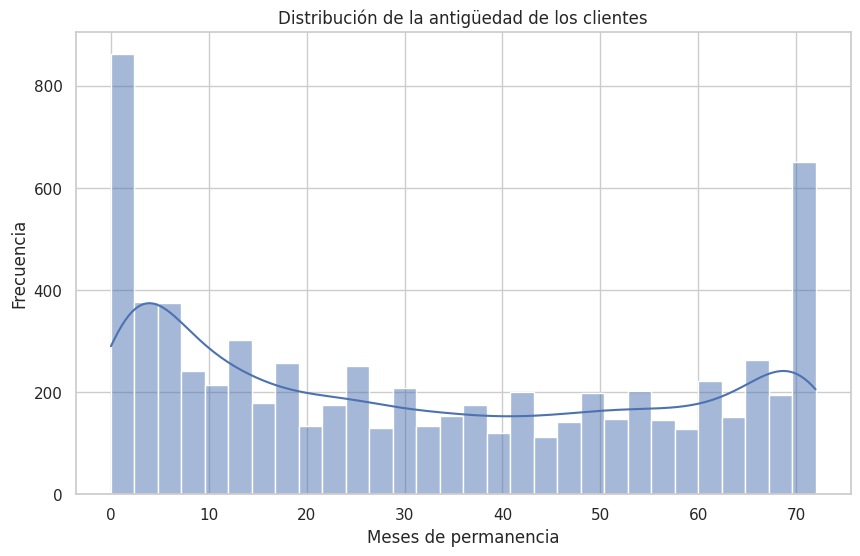

In [77]:
# Histograma de la antigüedad de los clientes
sns.histplot(df_clean['tenure'], bins=30, kde=True)
plt.title('Distribución de la antigüedad de los clientes')
plt.xlabel('Meses de permanencia')
plt.ylabel('Frecuencia')
plt.show()

#### Distribución de la antigüedad de los clientes (tenure)


Observamos una distribución con **dos concentraciones principales**:

* clientes muy nuevos (pocos meses)
* clientes con **muchos años en el servicio (cerca de 72 meses)**

Esto sugiere que existen dos perfiles claros:

* clientes recientes que están probando el servicio
* clientes muy fidelizados que llevan varios años con la empresa

También se observa que la antigüedad máxima es **72 meses**, lo que indica que el dataset incluye hasta **6 años de permanencia**.

### Gasto mensual

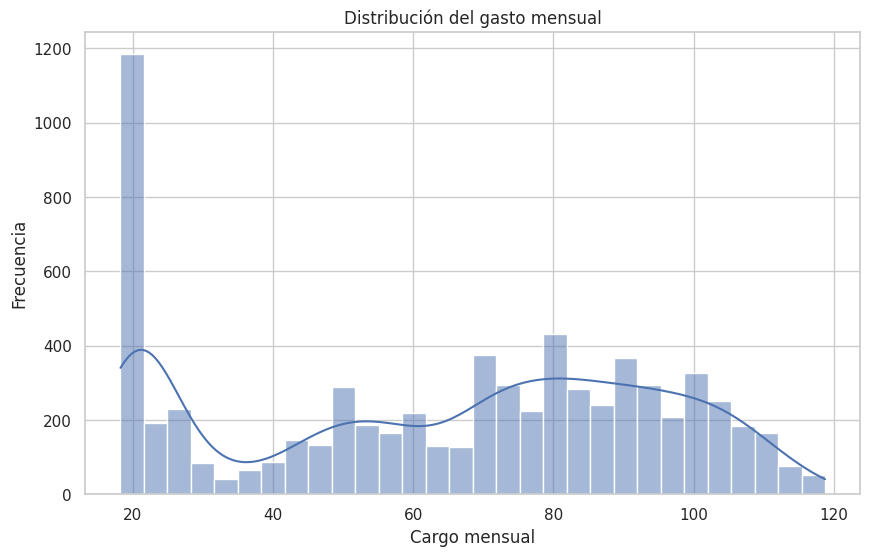

In [78]:
# Histograma del gasto mensual
sns.histplot(df_clean['MonthlyCharges'], bins=30, kde=True)
plt.title('Distribución del gasto mensual')
plt.xlabel('Cargo mensual')
plt.ylabel('Frecuencia')
plt.show()

#### Distribución del gasto mensual


El gasto mensual presenta **una distribución amplia** entre aproximadamente **20 y 120 unidades monetarias**.

Se observan dos grupos principales:

* clientes con **planes más económicos**
* clientes con **planes más completos o servicios adicionales**

Esto sugiere que Telecom X ofrece diferentes niveles de servicio o paquetes.

### Gasto total

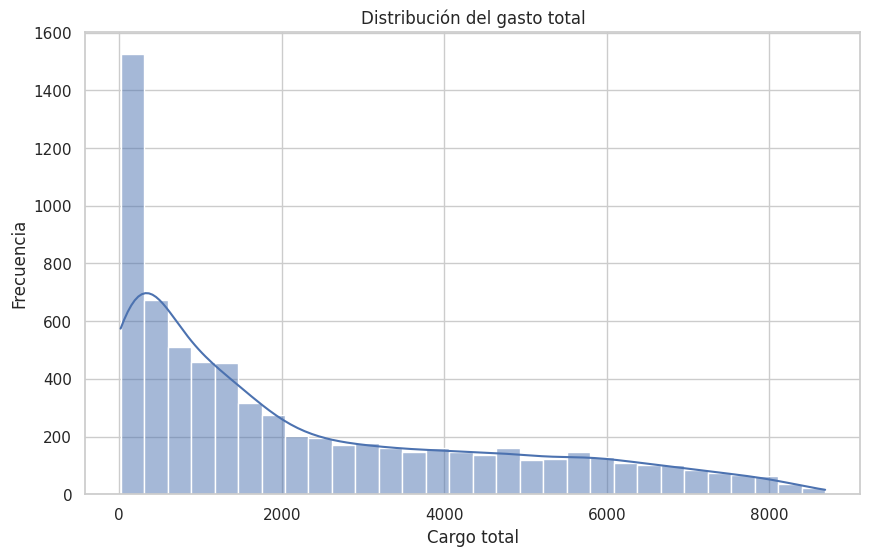

In [79]:
# Histograma del gasto total
sns.histplot(df_clean['TotalCharges'], bins=30, kde=True)
plt.title('Distribución del gasto total')
plt.xlabel('Cargo total')
plt.ylabel('Frecuencia')
plt.show()

#### Distribución del gasto total


El gasto total muestra una **distribución fuertemente asimétrica hacia la derecha**.

Esto ocurre porque:

* clientes nuevos tienen gasto total bajo
* clientes con mayor antigüedad acumulan cargos más altos

Por lo tanto, esta variable está fuertemente influenciada por la **antigüedad del cliente**.

### Cuentas diarias

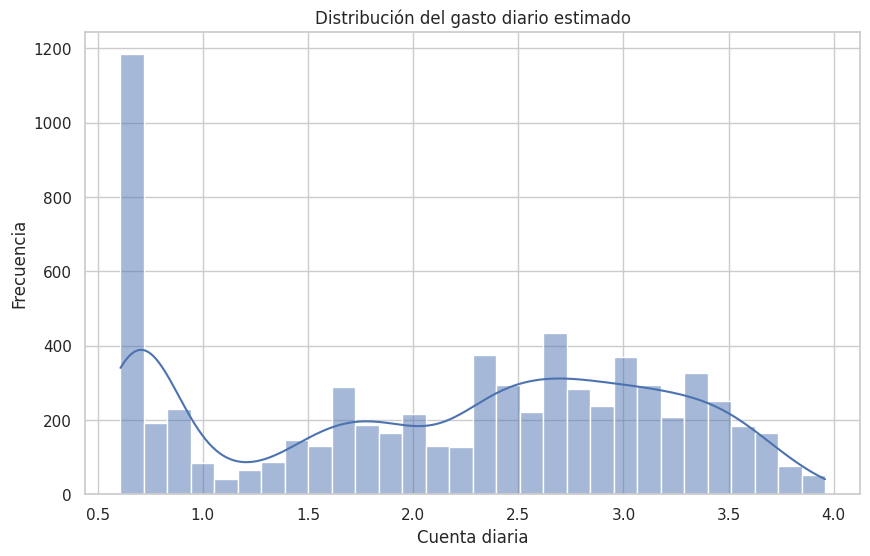

In [80]:
# Histograma de la cuenta diaria estimada
sns.histplot(df_clean['Cuentas_Diarias'], bins=30, kde=True)
plt.title('Distribución del gasto diario estimado')
plt.xlabel('Cuenta diaria')
plt.ylabel('Frecuencia')
plt.show()

#### Distribución del gasto diario estimado


La cuenta diaria estimada se concentra principalmente entre:

**2 y 3 unidades monetarias por día**

Esto es consistente con los valores de facturación mensual observados anteriormente.

La variable mantiene una forma similar a la distribución del gasto mensual, ya que se deriva directamente de ella.


## 3️⃣ Distribución de variables categóricas


También se analizan variables categóricas importantes para conocer qué perfiles de clientes predominan en el dataset.

### Género


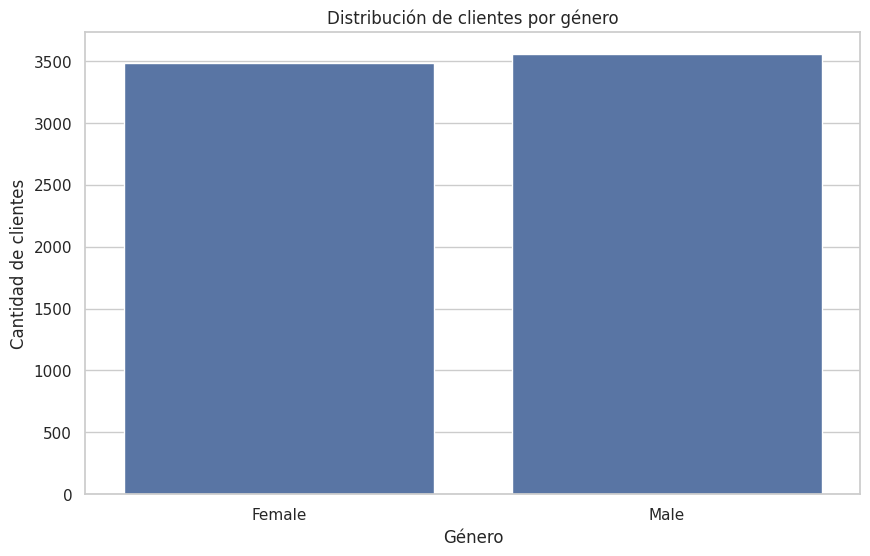

In [81]:
# Conteo por género
sns.countplot(x='gender', data=df_clean)
plt.title('Distribución de clientes por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de clientes')
plt.show()

#### Distribución por género


La cantidad de clientes por género es **muy equilibrada** entre hombres y mujeres.

Esto sugiere que el servicio **no presenta una segmentación fuerte por género**, lo cual puede indicar que el producto está dirigido a un público amplio.

### Tipo de contrato

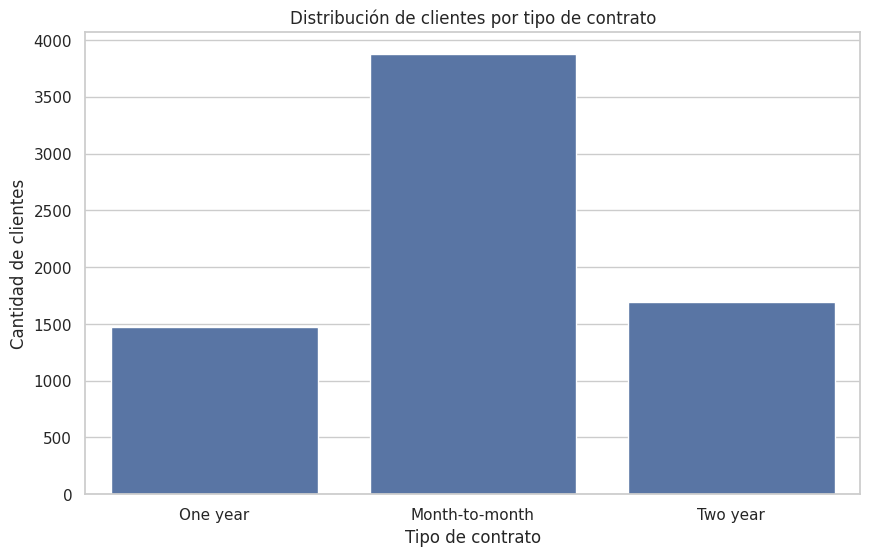

In [82]:
# Conteo por tipo de contrato
sns.countplot(x='Contract', data=df_clean)
plt.title('Distribución de clientes por tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')
plt.show()

#### Distribución por tipo de contrato


Se observa que la mayoría de los clientes tienen contrato:

**Month-to-month (mensual)**.

En menor proporción aparecen contratos:

* One year
* Two year

Esto indica que muchos clientes prefieren **flexibilidad en lugar de compromisos a largo plazo**.

Este factor podría influir posteriormente en la **tasa de abandono**.

### Servicio de internet


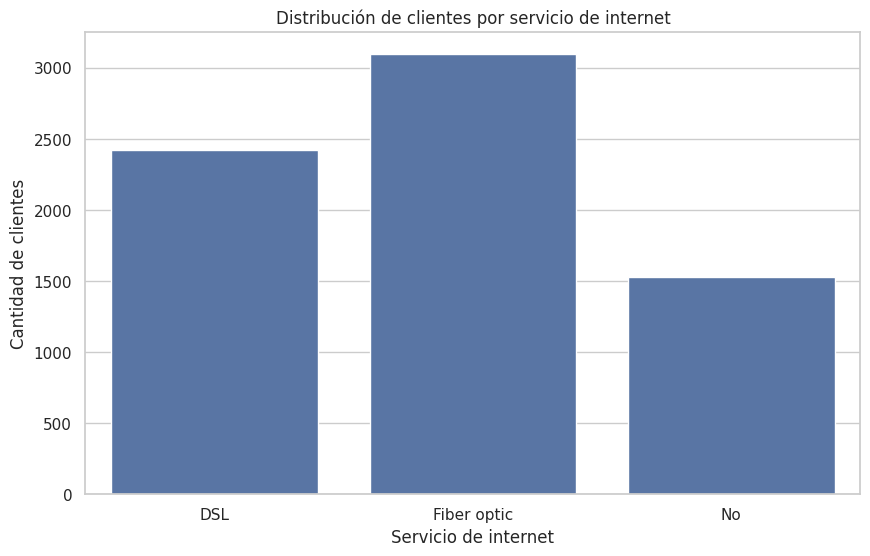

In [83]:
# Conteo por tipo de servicio de internet
sns.countplot(x='InternetService', data=df_clean)
plt.title('Distribución de clientes por servicio de internet')
plt.xlabel('Servicio de internet')
plt.ylabel('Cantidad de clientes')
plt.show()

#### Distribución por servicio de internet


El servicio más utilizado es:

**Fiber optic**

seguido por:

* DSL
* clientes sin servicio de internet

Esto indica que la empresa tiene una base importante de clientes con **internet de alta velocidad**.


### Método de pago

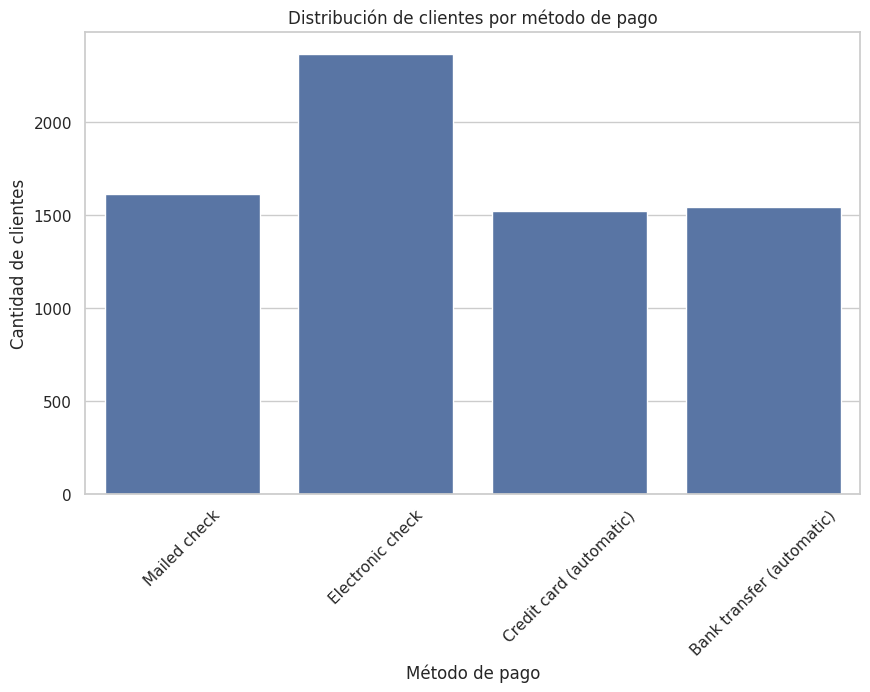

In [84]:
# Conteo por método de pago
sns.countplot(x='PaymentMethod', data=df_clean)
plt.title('Distribución de clientes por método de pago')
plt.xlabel('Método de pago')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45)
plt.show()

#### Distribución por método de pago


El método más utilizado es:

**Electronic check**.

Los demás métodos (tarjeta automática, transferencia bancaria y cheque por correo) aparecen con una distribución relativamente similar.

Esto podría sugerir diferencias en el comportamiento financiero de los clientes.

## Resultado del análisis descriptivo


El análisis descriptivo permitió comprender la estructura general del dataset y el perfil de los clientes de Telecom X.

Entre los hallazgos principales:

* existe una gran proporción de clientes con contratos mensuales;
* el gasto mensual presenta una distribución amplia;
* la antigüedad del cliente varía significativamente;
* y no se observa un sesgo importante en variables demográficas como el género.

Estos resultados sirven como base para avanzar hacia el análisis central del estudio:

## **la evasión de clientes (Churn)**

En la siguiente sección se analizará directamente la proporción de clientes que **abandonan el servicio frente a los que permanecen**.


# 9️⃣ Distribución de evasión (Churn)


En esta sección se analiza la variable objetivo del estudio: **Churn**, que indica si un cliente abandonó el servicio.

Recordemos que previamente la variable fue convertida a formato binario:

* **0 → cliente permanece**
* **1 → cliente cancela el servicio**

El objetivo de este análisis es observar **qué proporción de clientes abandona el servicio frente a los que permanecen**.


## 1️⃣ Conteo de clientes por estado de churn

Primero se observa la cantidad de clientes que permanecen y los que cancelan.


In [85]:
# Conteo de clientes por estado de churn
df_clean['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


También es útil calcular el **porcentaje de churn**:


In [86]:
# Porcentaje de churn
df_clean['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.463013
1,26.536987


## 2️⃣ Gráfico de distribución de churn

Para visualizar mejor la proporción de clientes que permanecen y los que cancelan, se utiliza un gráfico de conteo.


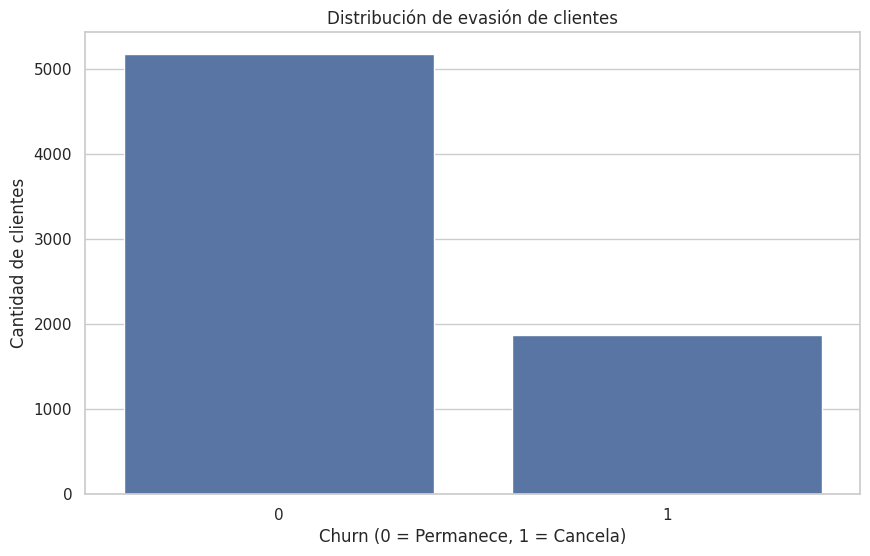

In [87]:
# Gráfico de distribución de churn
sns.countplot(x='Churn', data=df_clean)

plt.title('Distribución de evasión de clientes')
plt.xlabel('Churn (0 = Permanece, 1 = Cancela)')
plt.ylabel('Cantidad de clientes')

plt.show()

### Interpretación de la distribución de churn



A partir del análisis de la variable **Churn**, se observa la siguiente distribución:

| Estado del cliente | Cantidad | Porcentaje |
| ------------------ | -------- | ---------- |
| Permanece (0)      | 5174     | 73.46%     |
| Cancela (1)        | 1869     | 26.54%     |

Esto indica que aproximadamente **1 de cada 4 clientes abandona el servicio**.

La mayoría de los clientes se mantiene con la empresa, lo que sugiere que Telecom X logra retener a una parte importante de su base de usuarios. Sin embargo, el porcentaje de cancelación sigue siendo significativo y representa una oportunidad de mejora para la compañía.

Desde el punto de vista analítico, también se observa que el dataset presenta **un desbalance moderado de clases**, donde los clientes que permanecen superan ampliamente a los que cancelan. Este comportamiento es común en problemas de **análisis de churn**.

Comprender qué factores influyen en este 26% de cancelaciones será clave para diseñar estrategias que permitan **mejorar la retención de clientes**.


### Conclusión


El análisis de la distribución de churn permite identificar la magnitud del problema de evasión de clientes.

A partir de este punto, el objetivo del análisis será **identificar qué factores influyen en la cancelación del servicio**, analizando la relación entre churn y distintas variables del dataset.

En la siguiente sección se analizará cómo varía la evasión de clientes según **variables categóricas**, como el tipo de contrato, el método de pago o los servicios contratados.

# 🔟 Evasión por variables categóricas


En esta sección se analiza cómo varía la evasión de clientes (**Churn**) según distintas **variables categóricas** del dataset.

El objetivo es identificar si ciertas características de los clientes están asociadas con una mayor probabilidad de cancelación del servicio.

Se analizarán las siguientes variables:

* género (`gender`)
* tipo de contrato (`Contract`)
* método de pago (`PaymentMethod`)
* servicio de internet (`InternetService`)

Para visualizar estas relaciones se utilizarán principalmente:

* **countplot**
* **barplot**

## 1️⃣ Churn según género

Primero analizamos si existe alguna diferencia en la evasión de clientes entre hombres y mujeres.


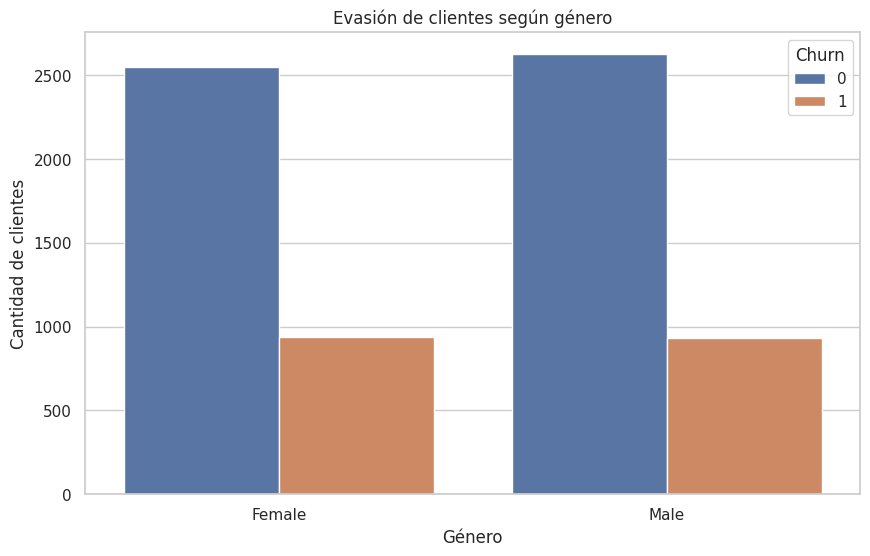

In [88]:
sns.countplot(x='gender', hue='Churn', data=df_clean)

plt.title('Evasión de clientes según género')
plt.xlabel('Género')
plt.ylabel('Cantidad de clientes')

plt.show()

### Interpretación


El gráfico muestra que la cantidad de clientes que cancelan el servicio es **muy similar entre hombres y mujeres**.

Esto indica que **el género no parece ser un factor relevante en la evasión de clientes**.

La proporción de cancelación se mantiene relativamente constante entre ambos grupos, lo que sugiere que la decisión de abandonar el servicio está más relacionada con otros factores como el contrato, el precio o los servicios contratados.


## 2️⃣ Churn según tipo de contrato


El tipo de contrato suele ser una de las variables más importantes en los análisis de churn.


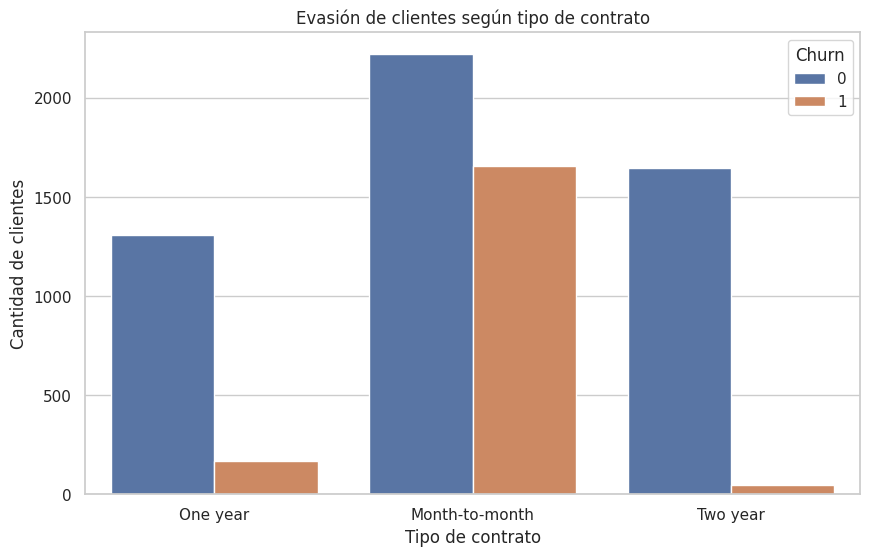

In [89]:
sns.countplot(x='Contract', hue='Churn', data=df_clean)

plt.title('Evasión de clientes según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')

plt.show()

### Interpretación


Este gráfico revela **uno de los patrones más claros del análisis**.

Los clientes con contrato **Month-to-month (mensual)** presentan una cantidad significativamente mayor de cancelaciones en comparación con los clientes que tienen contratos de **uno o dos años**.

En cambio, los contratos de mayor duración muestran **niveles muy bajos de churn**, lo que sugiere que los compromisos a largo plazo ayudan a mejorar la retención de clientes.

Este resultado indica que **la duración del contrato es uno de los factores más influyentes en la evasión de clientes**.

## 3️⃣ Churn según método de pago


El método de pago también puede influir en el comportamiento de cancelación.


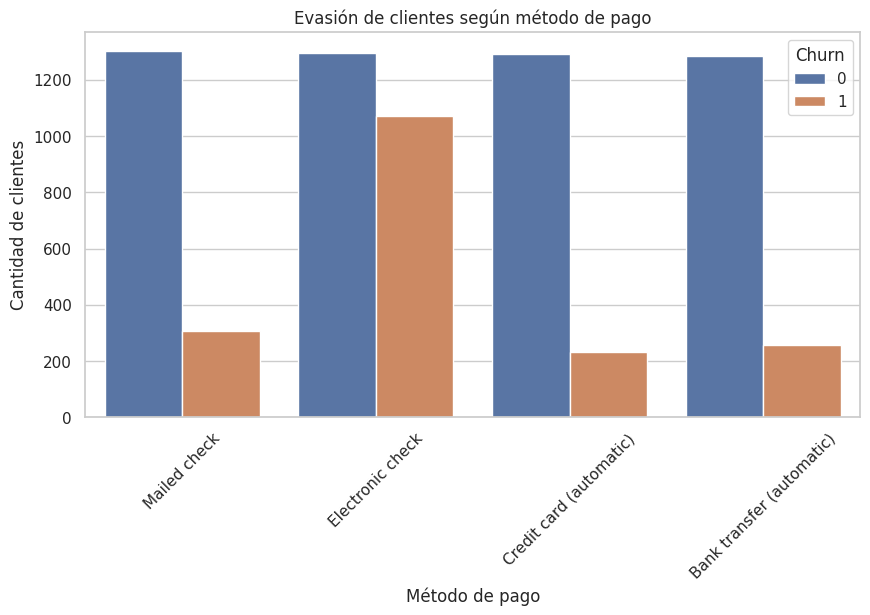

In [90]:
plt.figure(figsize=(10,5))

sns.countplot(x='PaymentMethod', hue='Churn', data=df_clean)

plt.title('Evasión de clientes según método de pago')
plt.xlabel('Método de pago')
plt.ylabel('Cantidad de clientes')

plt.xticks(rotation=45)

plt.show()

### Interpretación


Se observa que los clientes que utilizan **Electronic check** presentan una cantidad considerablemente mayor de cancelaciones en comparación con los demás métodos de pago.

Por el contrario, los métodos de pago automáticos como:

* tarjeta de crédito automática
* transferencia bancaria automática

presentan niveles de churn más bajos.

Esto podría indicar que los métodos de pago automáticos generan **mayor estabilidad en la relación con el cliente**, mientras que los métodos manuales facilitan la cancelación del servicio.

## 4️⃣ Churn según servicio de internet


Por último, se analiza si el tipo de servicio de internet está relacionado con la evasión de clientes.


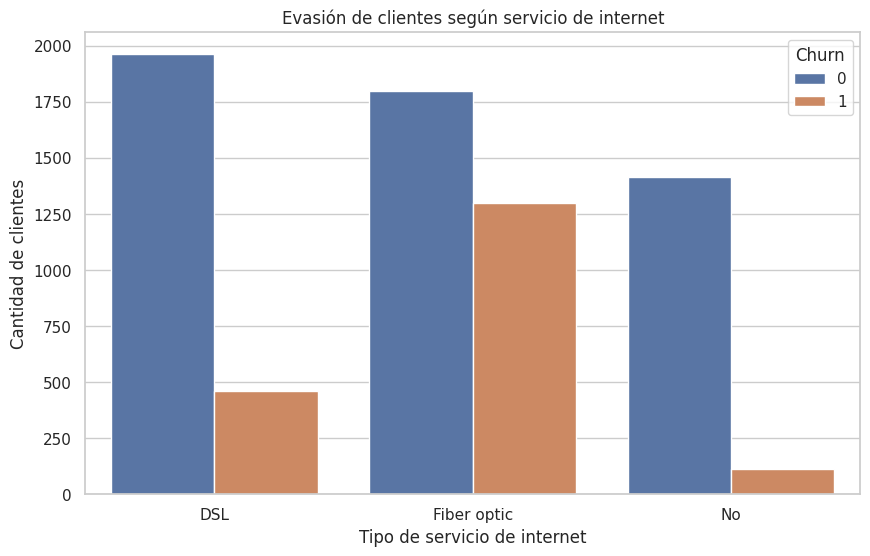

In [91]:
sns.countplot(x='InternetService', hue='Churn', data=df_clean)

plt.title('Evasión de clientes según servicio de internet')
plt.xlabel('Tipo de servicio de internet')
plt.ylabel('Cantidad de clientes')

plt.show()

### Interpretación


El análisis muestra que los clientes que utilizan **Fiber optic** presentan una mayor cantidad de cancelaciones en comparación con los clientes con **DSL** o aquellos que no tienen servicio de internet.

Esto podría estar relacionado con varios factores posibles:

* mayor costo del servicio
* expectativas más altas sobre la calidad del internet
* mayor competencia en servicios de alta velocidad

Por lo tanto, el tipo de servicio de internet también podría estar asociado con el comportamiento de cancelación.

## Conclusión del análisis categórico


A partir de este análisis se identificaron varios factores que parecen influir en la evasión de clientes:

**Factores con mayor relación con churn:**

* contratos mensuales (Month-to-month)
* método de pago Electronic check
* servicio de internet Fiber optic

**Factor con poca influencia:**

* género del cliente

Estos resultados sugieren que las decisiones de cancelación están más relacionadas con **condiciones contractuales y características del servicio** que con variables demográficas.

# 1️⃣1️⃣ Evasión por variables numéricas


En esta sección se analiza cómo se relaciona la evasión de clientes (**Churn**) con distintas **variables numéricas** del dataset.

El objetivo es identificar si existen diferencias en variables como:

* antigüedad del cliente (`tenure`)
* gasto mensual (`MonthlyCharges`)
* gasto total (`TotalCharges`)
* cuenta diaria estimada (`Cuentas_Diarias`)

entre los clientes que **permanecen** y los que **cancelan el servicio**.

Para visualizar estas diferencias se utilizarán principalmente:

* **boxplots** para comparar distribuciones
* **histplots** para observar la forma de las distribuciones

## 1️⃣ Churn según antigüedad del cliente


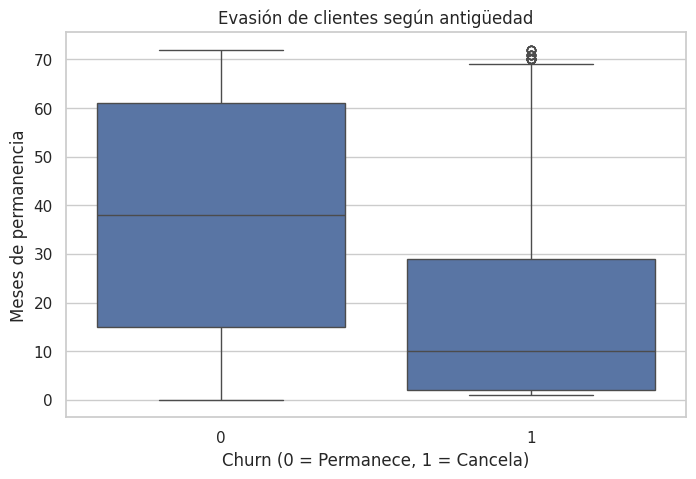

In [92]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df_clean)

plt.title('Evasión de clientes según antigüedad')
plt.xlabel('Churn (0 = Permanece, 1 = Cancela)')
plt.ylabel('Meses de permanencia')

plt.show()

### Interpretación


El boxplot muestra una diferencia clara entre los clientes que permanecen y los que cancelan el servicio.

Los clientes que **cancelan (Churn = 1)** tienen una **antigüedad significativamente menor** que aquellos que permanecen.

La mayoría de los clientes que abandonan el servicio lo hacen **durante los primeros meses de permanencia**, mientras que los clientes con mayor antigüedad tienden a mantenerse en la empresa.

Esto indica que **los primeros meses son críticos para la retención de clientes**, y que mejorar la experiencia inicial podría reducir la tasa de evasión.

## 2️⃣ Churn según gasto mensual


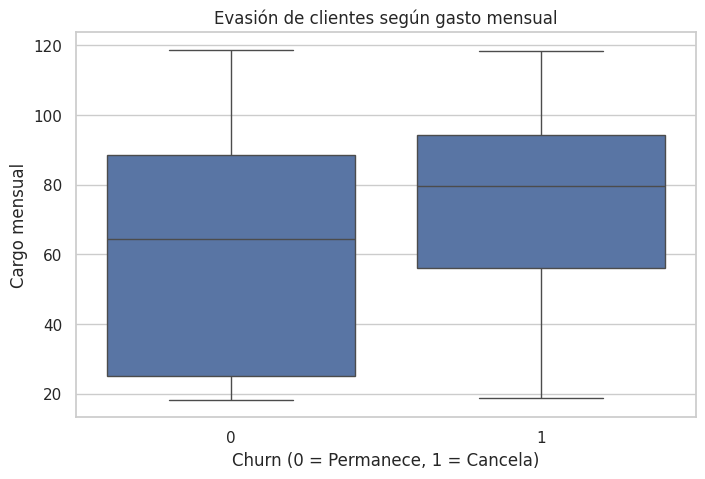

In [93]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean)

plt.title('Evasión de clientes según gasto mensual')
plt.xlabel('Churn (0 = Permanece, 1 = Cancela)')
plt.ylabel('Cargo mensual')

plt.show()

### Interpretación


El gráfico muestra que los clientes que cancelan el servicio presentan, en promedio, **gastos mensuales más altos** que los clientes que permanecen.

Esto puede indicar que los planes más costosos están asociados con **mayor probabilidad de cancelación**, posiblemente debido a:

* percepción de precio elevado
* comparación con ofertas de la competencia
* expectativas más altas sobre el servicio

Por lo tanto, el costo mensual podría ser **un factor relevante en el churn**.

## 3️⃣ Churn según gasto total


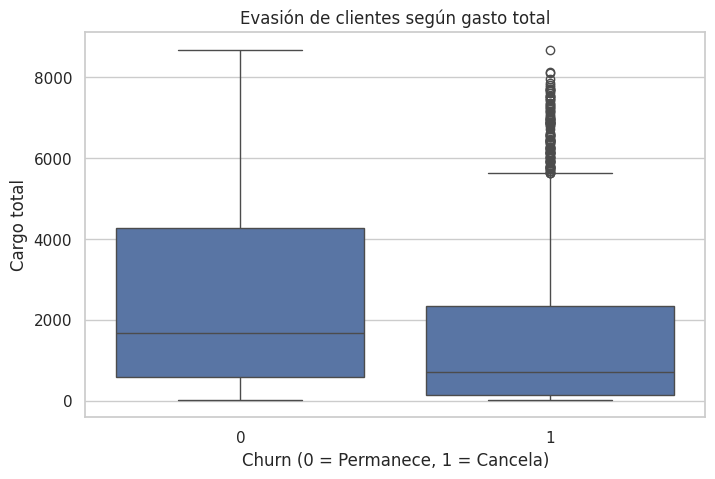

In [94]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='TotalCharges', data=df_clean)

plt.title('Evasión de clientes según gasto total')
plt.xlabel('Churn (0 = Permanece, 1 = Cancela)')
plt.ylabel('Cargo total')

plt.show()

### Interpretación


El gasto total acumulado es considerablemente mayor entre los clientes que permanecen en la empresa.

Esto ocurre porque los clientes con mayor antigüedad han pagado el servicio durante más tiempo.

En cambio, los clientes que cancelan tienden a presentar **valores bajos de gasto total**, lo cual refuerza la idea de que muchos abandonos ocurren **en etapas tempranas de la relación con la empresa**.

## 4️⃣ Churn según cuenta diaria estimada


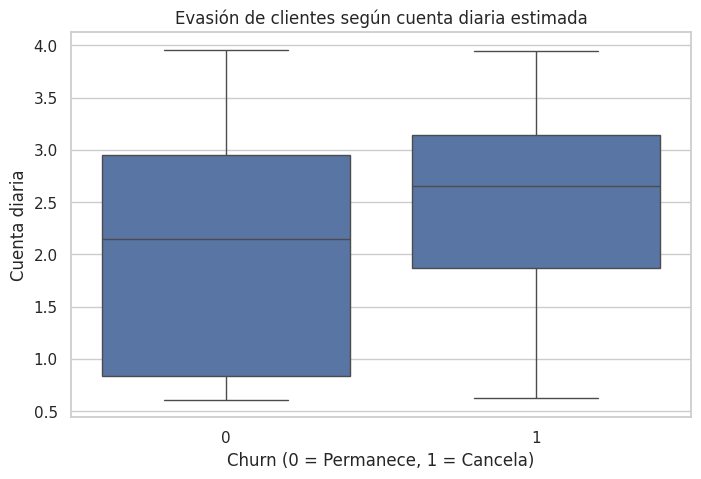

In [95]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='Cuentas_Diarias', data=df_clean)

plt.title('Evasión de clientes según cuenta diaria estimada')
plt.xlabel('Churn (0 = Permanece, 1 = Cancela)')
plt.ylabel('Cuenta diaria')

plt.show()

### Interpretación


El análisis muestra que los clientes que cancelan el servicio presentan **cuentas diarias ligeramente más altas**.

Esto sugiere que el costo del servicio también puede influir en la decisión de abandono, aunque la diferencia no es tan marcada como en el caso de la antigüedad.

## Distribución de variables numéricas según churn


También es útil visualizar la distribución completa de algunas variables mediante histogramas.


### Antigüedad


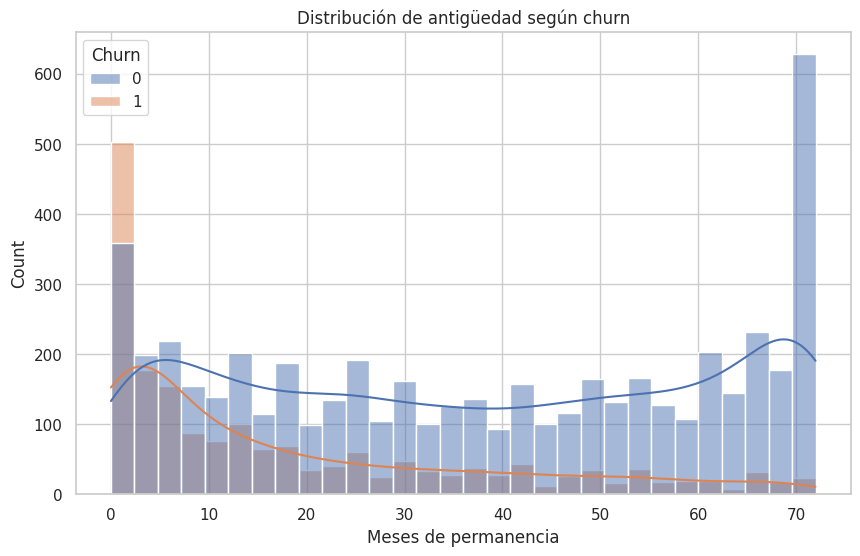

In [96]:
sns.histplot(data=df_clean, x='tenure', hue='Churn', bins=30, kde=True)

plt.title('Distribución de antigüedad según churn')
plt.xlabel('Meses de permanencia')

plt.show()

### Gasto mensual


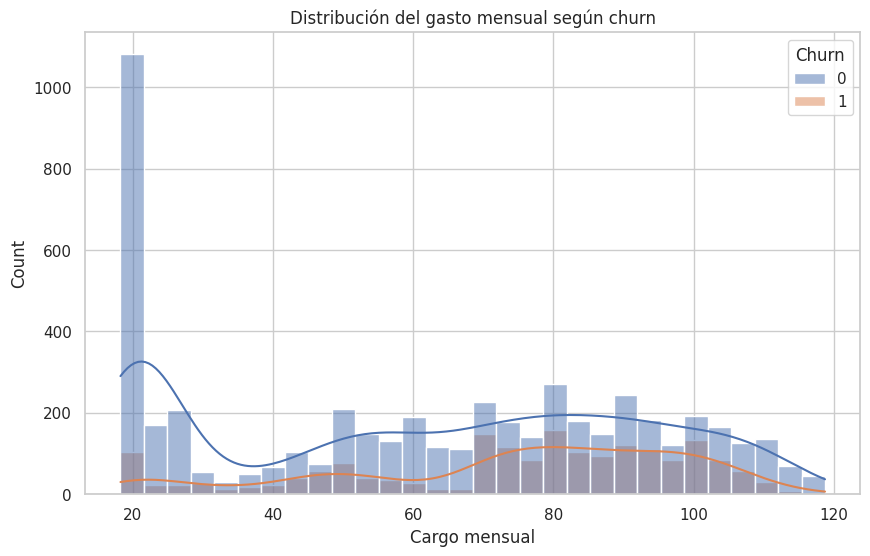

In [97]:
sns.histplot(data=df_clean, x='MonthlyCharges', hue='Churn', bins=30, kde=True)

plt.title('Distribución del gasto mensual según churn')
plt.xlabel('Cargo mensual')

plt.show()

## 📈 Distribuciones observadas


Los histogramas permiten observar mejor la distribución de los datos.

En el caso de la **antigüedad**, se observa que los clientes que cancelan se concentran principalmente en los **primeros meses de permanencia**, mientras que los clientes que permanecen están distribuidos a lo largo de todo el período.

Para el **gasto mensual**, los clientes que cancelan tienden a concentrarse en valores **medios y altos**, lo que podría indicar una relación entre el costo del servicio y la decisión de abandono.


# Conclusión del análisis numérico


l análisis de variables numéricas permite identificar algunos patrones importantes en el comportamiento de churn:

Los factores que parecen tener mayor relación con la evasión de clientes son:

* **baja antigüedad del cliente**
* **gastos mensuales más elevados**
* **menor gasto total acumulado**

Esto sugiere que muchos clientes cancelan el servicio **durante los primeros meses**, especialmente cuando perciben que el costo del servicio es alto.

Por lo tanto, estrategias de **retención temprana**, promociones iniciales o mejoras en la experiencia del cliente podrían ayudar a reducir la tasa de evasión.

# 1️⃣2️⃣ Análisis de correlación


El análisis de correlación permite identificar **relaciones entre variables numéricas del dataset**.

Para ello se calcula una **matriz de correlación**, que muestra qué tan relacionadas están las variables entre sí.

Los valores de correlación van entre:

* **1** → correlación positiva fuerte
* **0** → no hay relación
* **-1** → correlación negativa fuerte

Esto permite identificar variables que podrían influir en el **comportamiento de evasión de clientes (Churn)**.


## Calcular matriz de correlación


Primero seleccionamos las variables numéricas del dataset.


In [98]:
corr_matrix = df_clean.corr(numeric_only=True)

corr_matrix

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Cuentas_Diarias,Cantidad_Servicios
Churn,1.000000,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.191825,0.193356,-0.199484,0.193356,-0.087698
SeniorCitizen,0.150889,1.000000,0.016479,-0.211185,0.016567,0.008576,0.156530,0.220173,0.102411,0.220173,0.067493
Partner,-0.150448,0.016479,1.000000,0.452676,0.379697,0.017706,-0.014877,0.096848,0.319072,0.096848,0.204237
Dependents,-0.164221,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.111377,-0.113890,0.064653,-0.113890,0.030200
tenure,-0.352229,0.016567,0.379697,0.159712,1.000000,0.008448,0.006152,0.247900,0.825880,0.247900,0.494263
PhoneService,0.011942,0.008576,0.017706,-0.001762,0.008448,1.000000,0.016505,0.247398,0.113008,0.247398,-0.092810
PaperlessBilling,0.191825,0.156530,-0.014877,-0.111377,0.006152,0.016505,1.000000,0.352150,0.157830,0.352150,0.182481
MonthlyCharges,0.193356,0.220173,0.096848,-0.113890,0.247900,0.247398,0.352150,1.000000,0.651065,1.000000,0.724706
TotalCharges,-0.199484,0.102411,0.319072,0.064653,0.825880,0.113008,0.157830,0.651065,1.000000,0.651065,0.746101
Cuentas_Diarias,0.193356,0.220173,0.096848,-0.113890,0.247900,0.247398,0.352150,1.000000,0.651065,1.000000,0.724706


## Visualización con heatmap


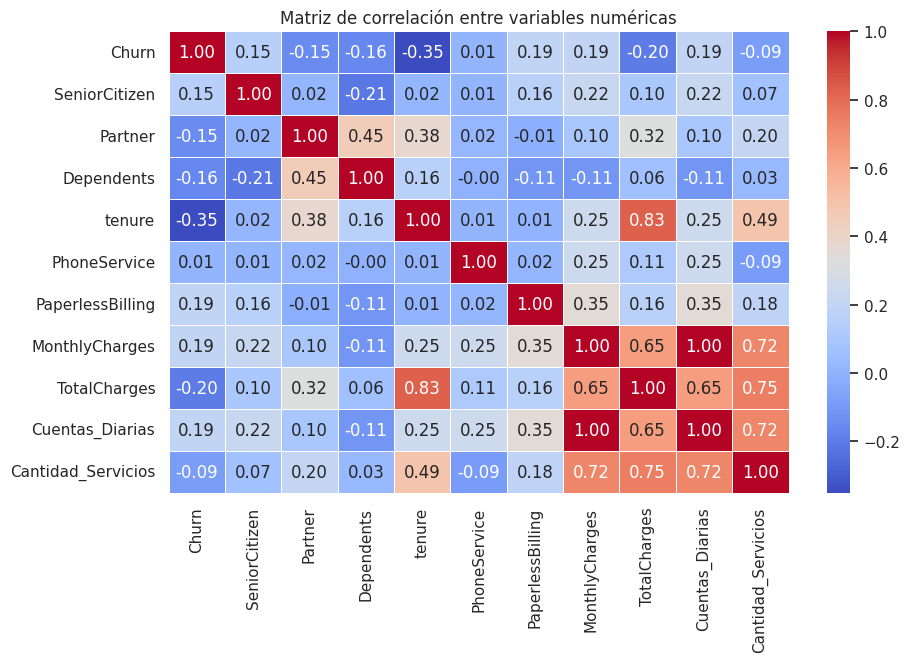

In [99]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Matriz de correlación entre variables numéricas')

plt.show()

## Interpretación del análisis de correlación

La matriz de correlación permite identificar qué variables numéricas están más relacionadas entre sí y cuáles presentan una mayor asociación con la **evasión de clientes (`Churn`)**.


## Relación entre churn y otras variables


Al observar la fila/columna de **`Churn`**, se destacan las siguientes correlaciones:

* **`tenure`** presenta una correlación **negativa moderada** con churn (**-0.35**).
  Esto indica que **cuanto mayor es la antigüedad del cliente, menor es la probabilidad de cancelación**.
  Este resultado coincide con el análisis anterior, donde se observó que muchos clientes abandonan el servicio en los primeros meses.

* **`MonthlyCharges`** presenta una correlación **positiva débil** con churn (**0.19**).
  Esto sugiere que los clientes con **gastos mensuales más altos** tienen una ligera tendencia a cancelar más.

* **`Cuentas_Diarias`** también muestra una correlación **positiva débil** con churn (**0.19**).
  Este resultado es esperable, ya que esta variable se deriva del gasto mensual.

* **`TotalCharges`** presenta una correlación **negativa débil a moderada** con churn (**-0.20**).
  Esto sugiere que los clientes con mayor gasto total acumulado tienden a permanecer en la empresa, probablemente porque llevan más tiempo como clientes.

* **`PaperlessBilling`** presenta una correlación positiva débil con churn (**0.19**), lo que podría indicar que los clientes con facturación electrónica tienen una ligera mayor tendencia a cancelar.

* **`Partner`** y **`Dependents`** presentan correlaciones negativas débiles con churn (**-0.15** y **-0.16** respectivamente), lo que podría sugerir que los clientes con vínculos familiares muestran algo más de estabilidad.


## Relaciones importantes entre variables numéricas


Además del churn, hay relaciones fuertes entre otras variables del dataset:

* **`tenure` y `TotalCharges`** tienen una correlación **positiva fuerte** (**0.83**).
  Esto tiene sentido: cuanto más tiempo permanece un cliente en la empresa, más gasto total acumula.

* **`MonthlyCharges` y `Cuentas_Diarias`** tienen correlación **perfecta** (**1.00**).
  Esto es completamente esperable, ya que `Cuentas_Diarias` fue calculada directamente a partir de `MonthlyCharges`.

* **`MonthlyCharges` y `Cantidad_Servicios`** presentan una correlación **positiva alta** (**0.72**).
  Esto sugiere que los clientes con más servicios contratados suelen pagar más mensualmente.

* **`TotalCharges` y `Cantidad_Servicios`** muestran una correlación **positiva alta** (**0.75**).
  Esto indica que los clientes con más servicios y mayor permanencia acumulan un mayor gasto total.


## Conclusión del análisis de correlación


El análisis de correlación refuerza varios de los hallazgos obtenidos en el EDA:

### Factores más relacionados con la evasión de clientes:

* **menor antigüedad del cliente**
* **mayor gasto mensual**
* **menor gasto total acumulado**

Entre todos ellos, la variable que muestra la relación más fuerte con churn es:
### **`tenure` (antigüedad del cliente)**

Esto sugiere que la evasión de clientes está especialmente asociada con la etapa inicial de la relación con la empresa.

#📄Informe final

# 1️⃣3️⃣ Insights principales


A partir del análisis exploratorio de datos se identificaron varios patrones relevantes relacionados con la **evasión de clientes (Churn)**.

El análisis permitió observar qué variables parecen tener mayor influencia en la decisión de los clientes de cancelar el servicio.

## Patrones identificados


### Antigüedad del cliente (Tenure)


Uno de los patrones más claros es que los clientes con **menor antigüedad presentan mayor probabilidad de cancelar el servicio**.

Muchos clientes abandonan la empresa durante los **primeros meses de permanencia**, mientras que los clientes con mayor antigüedad muestran niveles mucho más bajos de evasión.

Esto sugiere que **la retención temprana de clientes es clave para reducir el churn**.

### Tipo de contrato


Los clientes con contratos **Month-to-month** presentan la mayor cantidad de cancelaciones.

Por el contrario, los clientes con contratos de **uno o dos años** muestran tasas de evasión considerablemente menores.

Esto indica que los contratos de mayor duración generan **mayor estabilidad en la relación con el cliente**.


### Gasto mensual


Los clientes que cancelan el servicio tienden a tener **gastos mensuales más elevados**.

Esto podría indicar que los planes con costos más altos pueden aumentar la probabilidad de cancelación, especialmente si los clientes perciben que el servicio no justifica el precio.


### Método de pago


El método de pago **Electronic Check** presenta una mayor proporción de cancelaciones en comparación con otros métodos.

En cambio, los métodos automáticos como:

* tarjeta de crédito automática
* transferencia bancaria automática

parecen estar asociados con **menores tasas de churn**.

Esto podría deberse a que los pagos automáticos generan mayor continuidad en el servicio.


### Tipo de servicio de internet


Los clientes que utilizan **Fiber Optic** presentan una mayor cantidad de cancelaciones en comparación con los clientes que utilizan **DSL**.

Esto podría estar relacionado con el costo del servicio o con expectativas más altas sobre la calidad del internet.


## Variables que parecen influir más en la evasión


De acuerdo con los análisis realizados, las variables que muestran mayor relación con el churn son:

**Variables más influyentes:**

* antigüedad del cliente (**tenure**)
* tipo de contrato
* gasto mensual (**MonthlyCharges**)
* método de pago
* tipo de servicio de internet

**Variables con menor influencia:**

* género
* servicio telefónico
* características demográficas básicas


# 1️⃣4️⃣ Conclusiones


A partir del análisis exploratorio de datos realizado sobre la base de clientes de Telecom X, fue posible identificar varios patrones relevantes asociados con la evasión de clientes (**churn**).

Uno de los hallazgos más importantes es que **la antigüedad del cliente es uno de los factores más determinantes en la permanencia en la empresa**. Los clientes con menor tiempo de permanencia presentan una mayor probabilidad de cancelar el servicio, lo que indica que los primeros meses de relación con la compañía son un período crítico para la retención.

Además, se observó que los clientes con **contratos mensuales (month-to-month)** presentan niveles de evasión significativamente mayores que aquellos con contratos de uno o dos años. Esto sugiere que los contratos a largo plazo ayudan a fortalecer el compromiso del cliente con la empresa.

El análisis también mostró que **los clientes con gastos mensuales más altos tienden a cancelar con mayor frecuencia**, lo que podría estar relacionado con la percepción del valor del servicio o con la existencia de alternativas más competitivas en el mercado.

En cuanto a los métodos de pago, los clientes que utilizan **electronic check** presentan una mayor proporción de cancelaciones en comparación con los clientes que utilizan métodos de pago automáticos, como tarjeta de crédito o transferencia bancaria. Esto podría indicar que los pagos automáticos contribuyen a una mayor estabilidad en la relación con el cliente.

Por otro lado, variables demográficas como el **género** mostraron poca influencia en la evasión de clientes, lo que sugiere que el comportamiento de cancelación está más relacionado con factores contractuales, económicos y de servicio.

En conjunto, los resultados indican que la evasión de clientes está principalmente asociada con **clientes nuevos, contratos flexibles y costos de servicio relativamente altos**. Comprender estos patrones permite identificar oportunidades para implementar estrategias de retención más efectivas y mejorar la experiencia del cliente.

# 1️⃣5️⃣ Recomendaciones estratégicas


A partir de los patrones identificados en el análisis exploratorio de datos, se pueden proponer diversas estrategias orientadas a **reducir la evasión de clientes (churn)** y mejorar la retención.

Estas recomendaciones se basan en las variables que mostraron mayor relación con el comportamiento de cancelación.


## Incentivar contratos de largo plazo


Dado que los clientes con contratos **month-to-month** presentan mayores tasas de evasión, una estrategia efectiva podría ser incentivar la adopción de contratos de mayor duración.

La empresa podría ofrecer:

* descuentos por contratos de **uno o dos años**
* beneficios adicionales para clientes con compromisos a largo plazo
* promociones de migración desde contratos mensuales hacia contratos anuales

Esto podría aumentar el nivel de compromiso de los clientes con el servicio.


## Fortalecer la retención de nuevos clientes


El análisis mostró que la evasión ocurre principalmente durante los **primeros meses de permanencia**.

Por ello, se recomienda implementar estrategias específicas para mejorar la experiencia de los clientes nuevos, tales como:

* programas de **bienvenida o onboarding**
* soporte técnico prioritario durante los primeros meses
* seguimiento de satisfacción del cliente
* promociones iniciales o descuentos de fidelización

Estas acciones pueden ayudar a construir una relación más sólida desde el comienzo.


## Evaluar los planes con mayor costo mensual


Se observó que los clientes con **gastos mensuales más altos** presentan una mayor tendencia a cancelar el servicio.

La empresa podría analizar:

* la competitividad de sus planes más costosos
* la percepción de valor del servicio ofrecido
* posibles mejoras en los paquetes de servicios

También podría ser útil ofrecer **opciones de planes intermedios o personalizables** que se ajusten mejor a las necesidades de los clientes.


## Promover métodos de pago automáticos


El método de pago **Electronic Check** presenta una mayor proporción de cancelaciones.

Por ello, se podría incentivar el uso de métodos de pago automáticos como:

* tarjeta de crédito automática
* transferencia bancaria automática

Esto podría lograrse mediante:

* pequeños descuentos
* beneficios adicionales
* procesos de activación más simples

Los pagos automáticos suelen generar **mayor continuidad en el servicio**.


## Analizar servicios asociados a mayor churn


El análisis también sugiere que algunos servicios, como el **internet de fibra óptica**, presentan mayores niveles de cancelación.

Sería recomendable investigar con mayor profundidad:

* la calidad percibida del servicio
* problemas técnicos recurrentes
* expectativas de los clientes sobre este tipo de servicio

Comprender estas causas podría ayudar a **mejorar la satisfacción del cliente y reducir cancelaciones**.


# Conclusión final del proyecto


El análisis exploratorio permitió identificar factores clave asociados con la evasión de clientes, destacando la importancia de la antigüedad del cliente, el tipo de contrato, el costo del servicio y el método de pago.

Estos hallazgos proporcionan información valiosa que puede ayudar a Telecom X a diseñar **estrategias de retención más efectivas**, mejorar la experiencia del cliente y reducir la pérdida de clientes a largo plazo.
